#ML4Net - Lab 1

## Team members

Marc Rodríguez (267283) | Christopher Matienzo (251417) | Isaac Pérez (268275) | Daniel Yearwood (268690)

## Description

In this lab, you are going to get introduced into Multi-Armed Bandits (MABs) and Wi-Fi simulations. More specifically, you are going to implement a MAB algorithm that performs channel allocation in an Overlapping Basic Service Set (OBSS), i.e., in a scenario where multiple independent BSSs coexist.

## Instructions

*   Follow the steps from this Notebook and complete the proposed exercises.
*   Deliver the completed Notebook by uploading it to your Github repository.
*   Submission deadline: 18 May 2025 (EoB).

## Setting up the environment

1. Connect your Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


2. Download the Simulator's source code

In [ ]:
!wget https://github.com/fwilhelmi/fwilhelmi.github.io/raw/refs/heads/master/files/Komondor-lightweight.zip

--2025-05-17 19:21:59--  https://github.com/fwilhelmi/fwilhelmi.github.io/raw/refs/heads/master/files/Komondor-lightweight.zip
Resolving github.com (github.com)... 140.82.112.4
Connecting to github.com (github.com)|140.82.112.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/fwilhelmi/fwilhelmi.github.io/refs/heads/master/files/Komondor-lightweight.zip [following]
--2025-05-17 19:22:00--  https://raw.githubusercontent.com/fwilhelmi/fwilhelmi.github.io/refs/heads/master/files/Komondor-lightweight.zip
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 979661 (957K) [application/zip]
Saving to: ‘Komondor-lightweight.zip’

Komondor-lightweigh 100%[===================>] 956.70K  --.-KB/s    in 0.06s   

3. Define the main path of the code

In [ ]:
mypath="/content/drive/Shareddrives/MLNETWORKS/LABS/LAB1"

4. Extract the source code

In [ ]:
mkdir $mypath; cp Komondor-lightweight.zip $mypath; cd $mypath; unzip Komondor-lightweight.zip

mkdir: cannot create directory ‘/content/drive/Shareddrives/MLNETWORKS/LABS/LAB1’: File exists
Archive:  Komondor-lightweight.zip
replace config_models? [y]es, [n]o, [A]ll, [N]one, [r]ename: A
  inflating: config_models           
  inflating: learning_modules/ml_model.h  
  inflating: main/traffic_generator.h  
  inflating: methods/auxiliary_methods.h  
  inflating: input/agents_monitoring.csv  
  inflating: input/input_nodes.csv   
  inflating: structures/action.h     
  inflating: main/compcxx_komondor_main.h  
  inflating: main/komondor_main.cc   
  inflating: main/build_local        
  inflating: structures/controller_report.h  
  inflating: structures/performance.h  
  inflating: methods/modulations_methods.h  
  inflating: structures/logger.h     
  inflating: structures/node_configuration.h  
  inflating: learning_modules/pre_processor.h  

  inflating: structures/logical_nack.h  
  inflating: list_of_macros.h        
  inflating: structures/notification.h  
  inflating: main/a

5. Give permissions to run the code

In [ ]:
!cd $mypath/; chmod -R 777 *

6. Compile the code

In [ ]:
!cd $mypath/main; ./build_local

## How to run simulations

Komondor can be run by calling its compiled main file ("komondor_main") and indicating the value for different flags.

Next, you will see two different ways of running Komondor, depending on whether MAB Agents are instantiated or not.

In any case, **it is important to know** that:


*   Any input files used by the simulator will be located in the `/input` folder.
*   Any output files generated by the simulator will be located in the `/output` folder.

Apart from that, Komondor generates a set of console logs that give meaningful information.


### 1) Simulations without agents

To simulate specific scenarios (described using "input node" files) **without agents**, one must indicate the following flags:

In [ ]:
# DEFINE SIMULATION ARGUMENTS (NO AGENTS)

# Path of the file that describes the Wi-Fi nodes
INPUT_FILE_NODES='../input/input_nodes_ex_1_5.csv'

# Path of the file where output logs are going to be written
OUTPUT_FILE_LOGS='../output/logs_output_AAX_ex1.txt'

# Path of the file where output logs are going to be written
SIMULATION_CODE='AAX-LAB1-AGENTS'

# Flag to indicate whether "NODE LOGS" will be written into output files (1) or not (0)
FLAG_SAVE_NODE_LOGS=1

# Flag to indicate whether "SYSTEM LOGS" will be printed in the console (1) or not (0)
FLAG_PRINT_SYSTEM_LOGS=1

# Flag to indicate whether "NODE LOGS" will be printed in the console (1) or not (0)
FLAG_PRINT_NODE_LOGS=1

# Total simulated time (in seconds)
SIM_TIME=100

# Value of the random seed that initializes the random number generator
SEED=7

In [ ]:
# RUN THE SIMULATION

!cd $mypath/main; ./komondor_main $INPUT_FILE_NODES $OUTPUT_FILE_LOGS $SIMULATION_CODE $FLAG_SAVE_NODE_LOGS $FLAG_PRINT_SYSTEM_LOGS $FLAG_PRINT_NODE_LOGS $SIM_TIME $SEED


*************************************************************************************
 KOMONDOR Wireless Network Simulator
 Copyright (C) 2017-2022, and GNU GPL'd, by Sergio Barrachina & Francesc Wilhelmi
  - GitHub repository: https://github.com/wn-upf/Komondor
*************************************************************************************


 FULL configuration entered per console (AGENTS DISABLED).
 Komondor input configuration:
  - nodes_input_filename: ../input/input_nodes_ex_1_5.csv
  - agents_enabled: 0
  - script_output_filename: ../output/logs_output_AAX_ex1.txt
  - simulation_code: AAX-LAB1-AGENTS
  - save_node_logs: 1
  - print_system_logs: 1
  - print_node_logs: 1
  - sim_time: 100.000000 s
  - seed: 7

 Creating output files
  - Simulation output file 'output/logs_console_AAX-LAB1-AGENTS.txt' created!

 Reading system configuration file '../config_models'...
  - System environment properly set!

 Generating nodes DETERMINISTICALLY through NODES input file...
  - Read

### 2) Simulations with agents (used for keeping track of temporary performance)

To simulate specific scenarios (described using "input node" files) **with agents**, one must indicate the following flags:

In [ ]:
# DEFINE SIMULATION ARGUMENTS (WITH AGENTS FOR MONITORING PERFORMANCE)

# Path of the file that describes the Wi-Fi nodes
INPUT_FILE_NODES='../input/input_nodes_ex_1_5.csv'

# Path of the file that describes the agents associated with nodes
INPUT_FILE_AGENTS='../input/agents_monitoring_ex_1_2.csv'

# Path of the file where output logs are going to be written
OUTPUT_FILE_LOGS='../output/logs_output_AAX_ex1.txt'

# Path of the file where output logs are going to be written
SIMULATION_CODE='AAX-LAB1-AGENTS'

# Flag to indicate whether "NODE LOGS" will be written into output files (1) or not (0)
FLAG_SAVE_NODE_LOGS=0

# Flag to indicate whether "AGENT LOGS" will be written into output files (1) or not (0)
FLAG_SAVE_AGENT_LOGS=1

# Flag to indicate whether "SYSTEM LOGS" will be printed in the console (1) or not (0)
FLAG_PRINT_SYSTEM_LOGS=1

# Flag to indicate whether "NODE LOGS" will be printed in the console (1) or not (0)
FLAG_PRINT_NODE_LOGS=1

# Flag to indicate whether "AGENT LOGS" will be printed in the console (1) or not (0)
FLAG_PRINT_AGENT_LOGS=1

# Total simulated time (in seconds)
SIM_TIME=100

# Value of the random seed that initializes the random number generator
SEED=7

Run the simulation

In [ ]:
!cd $mypath/main; ./komondor_main $INPUT_FILE_NODES $INPUT_FILE_AGENTS $OUTPUT_FILE_LOGS $SIMULATION_CODE $FLAG_SAVE_NODE_LOGS $FLAG_SAVE_AGENT_LOGS $FLAG_PRINT_SYSTEM_LOGS $FLAG_PRINT_NODE_LOGS $FLAG_PRINT_AGENT_LOGS $SIM_TIME $SEED


*************************************************************************************
 KOMONDOR Wireless Network Simulator
 Copyright (C) 2017-2022, and GNU GPL'd, by Sergio Barrachina & Francesc Wilhelmi
  - GitHub repository: https://github.com/wn-upf/Komondor
*************************************************************************************


 FULL configuration entered per console (AGENTS ENABLED).
 Komondor input configuration:
  - nodes_input_filename: ../input/input_nodes_ex_1_5.csv
  - agents_enabled: 1
  - agents_input_filename: ../input/agents_monitoring_ex_1_2.csv
  - script_output_filename: ../output/logs_output_AAX_ex1.txt
  - simulation_code: AAX-LAB1-AGENTS
  - save_node_logs: 0
  - print_system_logs: 1
  - print_node_logs: 1
  - sim_time: 100.000000 s
  - seed: 7

 Creating output files
  - Simulation output file 'output/logs_console_AAX-LAB1-AGENTS.txt' created!

 Reading system configuration file '../config_models'...
  - System environment properly set!

 Generat

## EXERCISES

### **Exercise 1:**
Run the simulator (without agents) for the provided input nodes file (`/input/input_nodes.csv`). Before running the simulation, activate the flag that allows saving node logs into a file. After running the simulation, use the information from the log files of each node (e.g., AP_A, STA_A1, AP_B, STA_B1) to plot the scenario. To make the plot, consider the position of the nodes, the channel used, and the power strength that each node perceives from each other node in the deployment.

*Note: To know the power strength perceived by a given device (e.g., AP A) from any other devices (e.g., STA A1, AP B, STA B1), check the logs of that node and identify the cases where other nodes are detected to start/stop a transmission.*

In [ ]:
import re

# We define a function to find the id of a node
def nodeId(file):
    with open(file, 'r') as f:
        content = f.read()

    match = re.search(r'node_id\s*=\s*(\d+)', content)

    if match:
        return int(match.group(1))  # This captures the exact value
    else:
        return None

# We define a function to extract the power of transmission give a node
def powerTransmisions(nodeId, nodes, file):
    result = []
    processed_nodes = set()  # This set is used to avoid repetitions

    with open(file, 'r') as f:
        lines = f.readlines()

    for i, line in enumerate(lines):
        # We use this line since we know it from the log
        match = re.search(r'InportSomeNodeFinishTX\(\):\s*N(\d+)', line)
        if match:
            node_number = int(match.group(1))

            # We avoid repeating nodes
            if node_number in processed_nodes:
                continue

            if node_number == nodeId:
                processed_nodes.add(node_number)  # We mark the node as selected
                continue

            # Search for the power on the next 5 lines
            for j in range(1, 6):
                if i + j < len(lines):
                    next_line = lines[i + j]

                    # We use this line because we know it from the logs
                    power_match = re.search(
                        r'Power sensed per channel(?: BEFORE updating)? \[dBm\]:\s*(-?\d+\.\d+)',
                        next_line
                    )
                    if power_match:
                        power_value = float(power_match.group(1))
                        result.append([nodes[nodeId], nodes[node_number], power_value])
                        processed_nodes.add(node_number)  # We mark the node as processed
                        break

    return sorted(result)

In [ ]:
import pandas as pd, glob, re, numpy as np, matplotlib.pyplot as plt

# We load nodes and parameters of the node
base      = "drive/Shareddrives/MLNETWORKS/LABS/LAB1"
nodes     = pd.read_csv(f"{base}/input/input_nodes.csv", sep=';')
name_col  = 'node_code'
x_col     = 'x(m)'
y_col     = 'y(m)'
ch_col    = 'primary_channel'

# We extract the type of node (AP/STA) and (A/B)
def get_type_group(name):
    if 'AP_' in name:
        typee = 'AP'
    elif 'STA_' in name:
        typee = 'STA'
    else:
        typee = 'OTHER'
    group = name.split('_')[-1][0]
    return typee, group

nodes[['type', 'group']] = nodes[name_col].apply(lambda n: pd.Series(get_type_group(n)))

# Mapping nodes (N0 → AP_A), (N1 → STA_A)
id_map = { f"N{i}": n for i, n in enumerate(nodes[name_col]) }

# Extracting power per nodes
files = ["logs_output__N0_AP_A", "logs_output__N1_STA_A1", "logs_output__N2_AP_B", "logs_output__N3_STA_B1"]
name_nodes = ["AP_A", "STA_A1", "AP_B", "STA_B1"]

results = {}  # Dictionary to save dictionaries

for i, file in enumerate(files):
    value = nodeId(mypath + "/output/" + file + ".txt")
    dic = powerTransmisions(value, name_nodes, mypath + "/output/" + file + ".txt")
    results[i] = dic

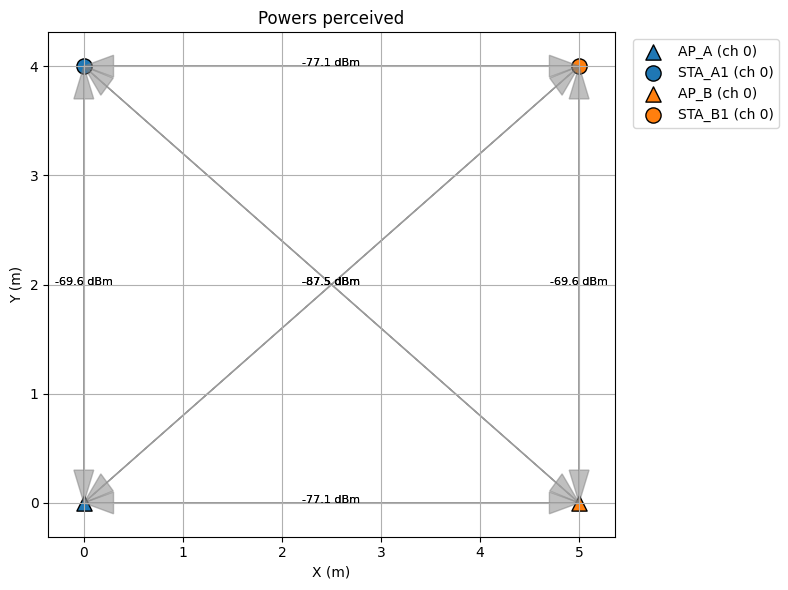

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Filtering only nodes that we want to show
nodes_filtered = nodes[nodes[name_col].isin(name_nodes)]

# Colors and markers for distinguish nodes
cmap        = plt.get_cmap('tab10')
groups      = sorted(nodes_filtered['group'].unique())
color_map   = { g: cmap(i) for i, g in enumerate(groups) }
marker_map  = { 'AP': '^', 'STA': 'o' }

plt.figure(figsize=(8, 6))

# Drawing nodes with color and shape according to its type
for _, r in nodes_filtered.iterrows():
    plt.scatter(r[x_col], r[y_col],
                s=120,
                c=[color_map[r['group']]],
                marker=marker_map[r['type']],
                edgecolors='k',
                label=f"{r[name_col]} (ch {r[ch_col]})")

# Arrows to describe power
idx = nodes_filtered.set_index(name_col)
drawn = set() # To avoid repetitions
for file, connections in results.items():
    for connection in connections:
        node1, node2, power = connection

        if node1 not in idx.index or node2 not in idx.index:
            continue

        x_t, y_t = idx.loc[node1, [x_col, y_col]].values
        x_r, y_r = idx.loc[node2, [x_col, y_col]].values

        dx, dy = x_r - x_t, y_r - y_t
        key = (node1, node2)
        if key in drawn:
            continue
        drawn.add(key)

        plt.arrow(x_t, y_t, dx, dy,
                  head_width=0.2, length_includes_head=True, alpha=0.5, color='gray')

        xm, ym = (x_t + x_r)/2, (y_t + y_r)/2
        plt.text(xm, ym, f"{power:.1f} dBm", fontsize=8, ha='center', color='black')

# Keys for nodes
h, l = plt.gca().get_legend_handles_labels()
by = dict(zip(l, h))
plt.legend(by.values(), by.keys(), bbox_to_anchor=(1.02, 1), loc='upper left')

plt.title("Powers perceived")
plt.xlabel("X (m)")
plt.ylabel("Y (m)")
plt.grid(True)
plt.tight_layout()
plt.show()


### **Exercise 2:**

Run the simulator (this time, with agents in "monitor" mode) for the provided input nodes file (`/input/input_nodes.csv`). The input agents file to be used is provided as (`/input/agents_monitoring.csv`). Ensure that the agent logs are saved into files by setting the corresponding flag to 1. After running the simulation, use the agent log files to plot the temporary throughput obtained by each AP.

In [ ]:
# DEFINE SIMULATION ARGUMENTS (WITH AGENTS FOR MONITORING PERFORMANCE)

# Path of the file that describes the Wi-Fi nodes
INPUT_FILE_NODES='../input/input_nodes_ex_1_5.csv'

# Path of the file that describes the agents associated with nodes
INPUT_FILE_AGENTS='../input/agents_monitoring_ex_1_2.csv'

# Path of the file where output logs are going to be written
OUTPUT_FILE_LOGS='../output/logs_output_AAX_ex2.txt'

# Path of the file where output logs are going to be written
SIMULATION_CODE='AAX-LAB1-AGENTS-ex2'

In [ ]:
!cd $mypath/main; ./komondor_main $INPUT_FILE_NODES $INPUT_FILE_AGENTS $OUTPUT_FILE_LOGS $SIMULATION_CODE $FLAG_SAVE_NODE_LOGS $FLAG_SAVE_AGENT_LOGS $FLAG_PRINT_SYSTEM_LOGS $FLAG_PRINT_NODE_LOGS $FLAG_PRINT_AGENT_LOGS $SIM_TIME $SEED


*************************************************************************************
 KOMONDOR Wireless Network Simulator
 Copyright (C) 2017-2022, and GNU GPL'd, by Sergio Barrachina & Francesc Wilhelmi
  - GitHub repository: https://github.com/wn-upf/Komondor
*************************************************************************************


 FULL configuration entered per console (AGENTS ENABLED).
 Komondor input configuration:
  - nodes_input_filename: ../input/input_nodes_ex_1_5.csv
  - agents_enabled: 1
  - agents_input_filename: ../input/agents_monitoring_ex_1_2.csv
  - script_output_filename: ../output/logs_output_AAX_ex2.txt
  - simulation_code: AAX-LAB1-AGENTS-ex2
  - save_node_logs: 0
  - print_system_logs: 1
  - print_node_logs: 1
  - sim_time: 100.000000 s
  - seed: 7

 Creating output files
  - Simulation output file 'output/logs_console_AAX-LAB1-AGENTS-ex2.txt' created!

 Reading system configuration file '../config_models'...
  - System environment properly set!



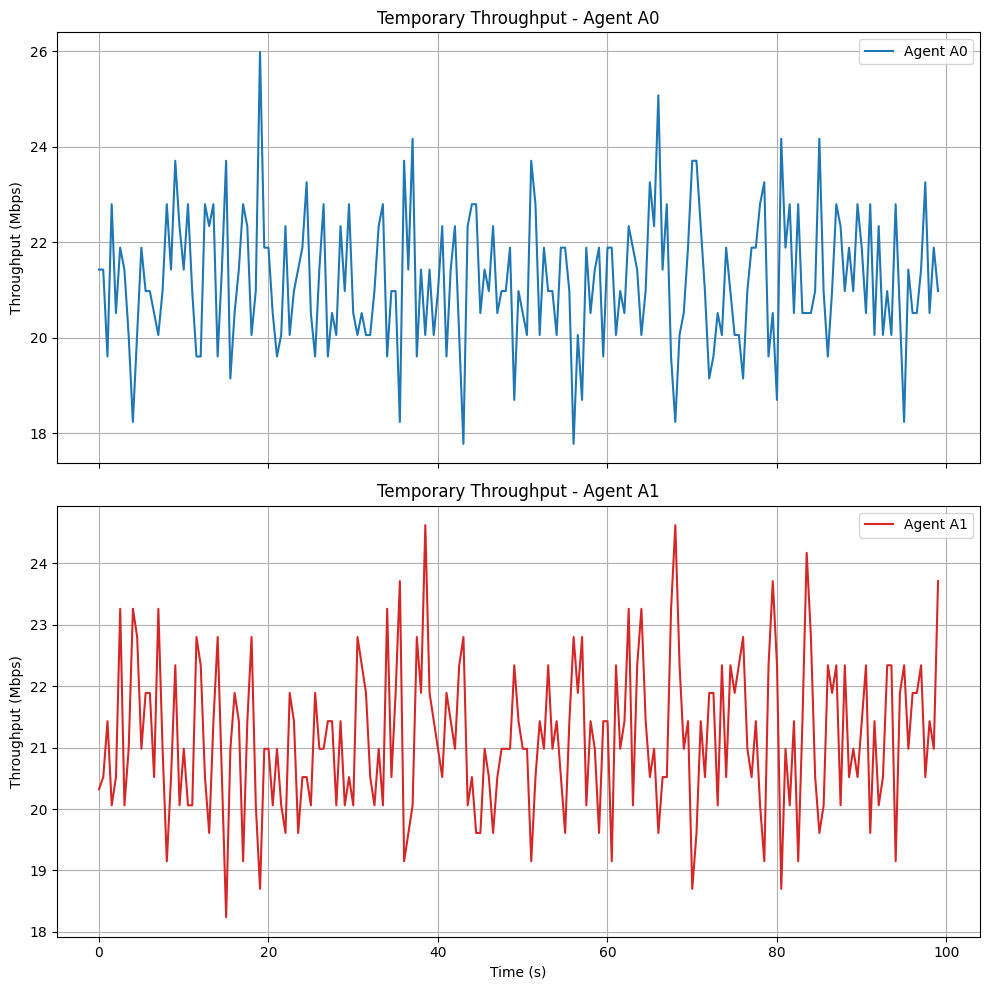

In [ ]:
import re
import pandas as pd
import matplotlib.pyplot as plt

# Paths of the files
filename_agent1 = "drive/Shareddrives/MLNETWORKS/LABS/LAB1/output/logs_output_AAX-LAB1-AGENTS-ex2_A0_A.txt"
filename_agent2 = "drive/Shareddrives/MLNETWORKS/LABS/LAB1/output/logs_output_AAX-LAB1-AGENTS-ex2_A1_B.txt"

# Reading files
with open(filename_agent1, 'r') as f:
    log1 = f.read()
with open(filename_agent2, 'r') as f:
    log2 = f.read()

# Pattern
pattern = re.compile(
    r'(?P<time>\d+\.\d+);(?P<agent>A\d);.*?Average throughput = (?P<throughput>[\d.]+) Mbps',
    re.DOTALL
)

# Extracting data
data1 = pattern.findall(log1)
data2 = pattern.findall(log2)

# Creating DataFrames with time and throughput
df1 = pd.DataFrame(data1, columns=['time', 'agent', 'throughput'])
df2 = pd.DataFrame(data2, columns=['time', 'agent', 'throughput'])

# Joining data
df = pd.concat([df1, df2], ignore_index=True)

# Converting types
df[['time', 'throughput']] = df[['time', 'throughput']].astype(float)

# Plotting different APs with different colors
agents = df['agent'].unique()
colors = ['tab:blue', 'tab:red']

fig, axes = plt.subplots(len(agents), 1, figsize=(10, 5 * len(agents)), sharex=True)

if len(agents) == 1:
    axes = [axes]

for ax, ap, color in zip(axes, agents, colors):
    grp = df[df['agent'] == ap]
    ax.plot(grp['time'], grp['throughput'], label=f'Agent {ap}', color=color)
    ax.set_title(f"Temporary Throughput - Agent {ap}")
    ax.set_ylabel("Throughput (Mbps)")
    ax.grid(True)
    ax.legend()

axes[-1].set_xlabel("Time (s)")
plt.tight_layout()
plt.show()

Throughput oscillates mainly between 18 and 25 Mbps, with significant peaks and dips throughout. This suggests that the default algorithm fails to stabilize throughput and fails to exploit more valid options (closer to 25 Mbps). We can see that it the mean of the fluctuations is close to 21 Mbps.

### **Exercise 3:**

Copy the `agents_monitoring.csv` file, rename it as `agents_egreedy.csv`, and modify it as follows:
- Indicate the possible "channel actions" by indicating `0,1` in the column 'actions channels' of each agent.
- Set the column "selected strategy" to `1` (which stands for ɛ-greedy) for each agent.
-Set the column "learning mechanism" to `1`.

Then, run the simulation using `agents_egreedy.csv` and plot the temporary throughput obtained by each AP, as done in Exercise 2. In addition, read the console logs from Komondor and explain the displayed agent logs.

**Important:** In case of experiencing a run-time error, check that the fields in the 'agents' file are separated by a semicolon (`;`).

In [ ]:
# DEFINE SIMULATION ARGUMENTS (WITH AGENTS FOR MONITORING PERFORMANCE)

# Path of the file that describes the Wi-Fi nodes
INPUT_FILE_NODES='../input/input_nodes_ex_1_5.csv'

# Path of the file that describes the agents associated with nodes
INPUT_FILE_AGENTS='../input/agents_egreedy_ex_3.csv'

# Path of the file where output logs are going to be written
OUTPUT_FILE_LOGS='../output/logs_output_AAX_ex3.txt'

# Path of the file where output logs are going to be written
SIMULATION_CODE='AAX-LAB1-EGREEDY-ex3'

In [ ]:
!cd $mypath/main; ./komondor_main $INPUT_FILE_NODES $INPUT_FILE_AGENTS $OUTPUT_FILE_LOGS $SIMULATION_CODE $FLAG_SAVE_NODE_LOGS $FLAG_SAVE_AGENT_LOGS $FLAG_PRINT_SYSTEM_LOGS $FLAG_PRINT_NODE_LOGS $FLAG_PRINT_AGENT_LOGS $SIM_TIME $SEED


*************************************************************************************
 KOMONDOR Wireless Network Simulator
 Copyright (C) 2017-2022, and GNU GPL'd, by Sergio Barrachina & Francesc Wilhelmi
  - GitHub repository: https://github.com/wn-upf/Komondor
*************************************************************************************


 FULL configuration entered per console (AGENTS ENABLED).
 Komondor input configuration:
  - nodes_input_filename: ../input/input_nodes_ex_1_5.csv
  - agents_enabled: 1
  - agents_input_filename: ../input/agents_egreedy_ex_3.csv
  - script_output_filename: ../output/logs_output_AAX_ex3.txt
  - simulation_code: AAX-LAB1-EGREEDY-ex3
  - save_node_logs: 0
  - print_system_logs: 1
  - print_node_logs: 1
  - sim_time: 100.000000 s
  - seed: 7

 Creating output files
  - Simulation output file 'output/logs_console_AAX-LAB1-EGREEDY-ex3.txt' created!

 Reading system configuration file '../config_models'...
  - System environment properly set!

 Ge

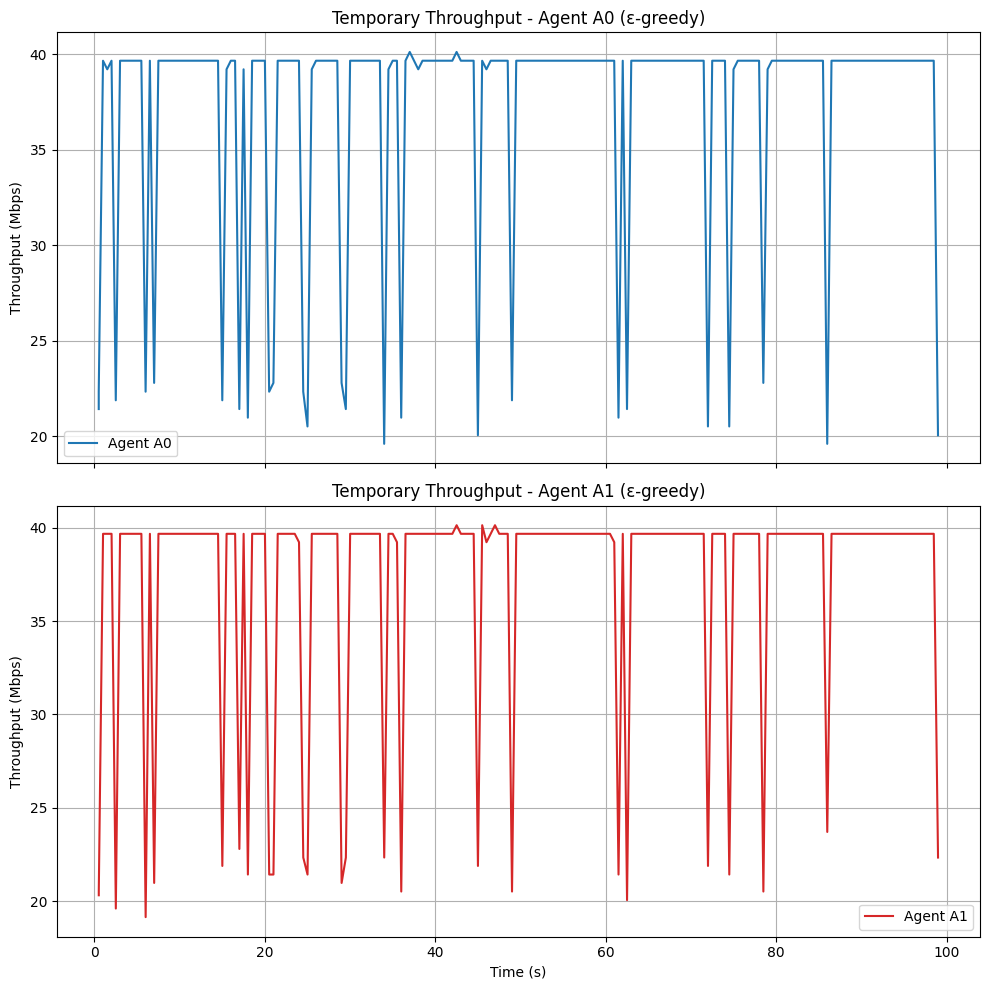

In [ ]:
import re
import pandas as pd
import matplotlib.pyplot as plt

# Paths of the files
filename_agent1 = "drive/Shareddrives/MLNETWORKS/LABS/LAB1/output/logs_output_AAX-LAB1-EGREEDY-ex3_A0_A.txt"
filename_agent2 = "drive/Shareddrives/MLNETWORKS/LABS/LAB1/output/logs_output_AAX-LAB1-EGREEDY-ex3_A1_B.txt"

# Reading files
with open(filename_agent1, 'r') as f:
    log1 = f.read()
with open(filename_agent2, 'r') as f:
    log2 = f.read()

# Pattern
pattern = re.compile(
    r'(?P<time>\d+\.\d+);(?P<agent>A\d);C03;.*?Average throughput = (?P<throughput>[\d.]+) Mbps',
    re.DOTALL
)

# Extracting data
data1 = pattern.findall(log1)
data2 = pattern.findall(log2)

# Creating DataFrames with time and throughput
df1 = pd.DataFrame(data1, columns=['time', 'agent', 'throughput'])
df2 = pd.DataFrame(data2, columns=['time', 'agent', 'throughput'])

# Joining data
df = pd.concat([df1, df2], ignore_index=True)

# Converting types
df[['time', 'throughput']] = df[['time', 'throughput']].astype(float)

# Plotting different APs with different colors using subplots
agents = df['agent'].unique()
colors = ['tab:blue', 'tab:red']

fig, axes = plt.subplots(len(agents), 1, figsize=(10, 5 * len(agents)), sharex=True)

if len(agents) == 1:
    axes = [axes]

for ax, ap, color in zip(axes, agents, colors):
    grp = df[df['agent'] == ap]
    ax.plot(grp['time'], grp['throughput'], label=f'Agent {ap}', color=color)
    ax.set_title(f"Temporary Throughput - Agent {ap} (ε-greedy)")
    ax.set_ylabel("Throughput (Mbps)")
    ax.grid(True)
    ax.legend()

axes[-1].set_xlabel("Time (s)")
plt.tight_layout()
plt.show()


Performance ranges mainly between 20 and 40 Mbps, with significant drops but usually staying above 35 and very close to 40 Mbps. This algorithm manages to maintain a very high and stable throughput where the decision that produces good results dominates and maintains it. This tells us that with e-greedy we have managed to quickly find a good option and exploit it most of the time.

### **Exercise 4:**
Create another input agents file (name it `agents_ml4net.csv`), but this time set the column "selected_strategy" (the last one) to 5.

The mechanism (as it is currently implemented) will just select actions randomly. For that reason, you have to define your own action-selection strategy by completing the code in `/learning_modules/network_optimization_methods/multi_armed_bandits.h`. More specifically, you will have to complete the function `PickArmML4Net()`, which contains all the logic. You can get inspiration from the other implemented MAB algorithms (e.g., UCB, Thompson sampling).

**IMPORTANT:** If you modify the source code, you will have to re-compile it (see step 6 in "Setting up the environment") before running new simulations.

In [ ]:
# (response to exercise 4)

# Our algorithm is the following:

# int PickArmML4Net(int num_arms, double *reward_per_arm, int *available_arms) {
#   printf("*******************EXECUTING PickArmML4Net*******************");
# 	double sum_exp = 0.0;
# 	double probs[num_arms];

# 	for (int i = 0; i < num_arms; i++) {
# 	  if (available_arms[i]) {
# 		  probs[i] = exp(reward_per_arm[i]);
# 			sum_exp += probs[i];
# 			} else {
# 				  probs[i] = 0.0;
# 			}
# 		}

# 		double r = ((double) rand() / RAND_MAX) * sum_exp;
# 		double cum_sum = 0.0;
# 		int best_arm = 0;

# 		for (int i = 0; i < num_arms; i++) {
# 		  cum_sum += probs[i];
# 			if (r <= cum_sum) {
# 			  best_arm = i;
# 				break;
# 			}
# 		}

# 		return best_arm;
# }


# It is a probabilistic algorithm that gives probabilities proportional to the reward of the arm.
# That is, the arm with highest reward is the arm with highest probability to be chosen.
# It is similar to a softmax but without the normalization step.

# First we initialize the cumulative sum and an array for saving the probabilities.
# If an arm is available, we save in its position its exponential probability (e^reward).
# We sum the total amount of probability (we will use it later to generate the random value).
# If the arm is not available, we assign it a probability of 0.

# Now we generate a random number r between 0 and the sum of probabilities.
# We initialize a new counter to sum the probabilities and the variable to assign the best arm.
# We cross the array and we accumulate the sum of probabilities in this new variable.
# If this new sum is higher than the value r generated the last visited arm will be the chosen one.

### **Exercise 5:**

Run a simulation to test your action-selection strategy. Compare it to ɛ-greedy (Exercise 3) by plotting the temporary throughput obtained by each of the mechanisms.

In [ ]:
# DEFINE SIMULATION ARGUMENTS (WITH AGENTS FOR MONITORING PERFORMANCE)

# Path of the file that describes the Wi-Fi nodes
INPUT_FILE_NODES='../input/input_nodes_ex_1_5.csv'

# Path of the file that describes the agents associated with nodes
INPUT_FILE_AGENTS='../input/agents_ml4net_5.csv'

# Path of the file where output logs are going to be written
OUTPUT_FILE_LOGS='../output/logs_output_AAX_ex5.txt'

# Path of the file where output logs are going to be written
SIMULATION_CODE='AAX-LAB1-AGENTS-ex5'

In [ ]:
!cd $mypath/main; ./komondor_main $INPUT_FILE_NODES $INPUT_FILE_AGENTS $OUTPUT_FILE_LOGS $SIMULATION_CODE $FLAG_SAVE_NODE_LOGS $FLAG_SAVE_AGENT_LOGS $FLAG_PRINT_SYSTEM_LOGS $FLAG_PRINT_NODE_LOGS $FLAG_PRINT_AGENT_LOGS $SIM_TIME $SEED


*************************************************************************************
 KOMONDOR Wireless Network Simulator
 Copyright (C) 2017-2022, and GNU GPL'd, by Sergio Barrachina & Francesc Wilhelmi
  - GitHub repository: https://github.com/wn-upf/Komondor
*************************************************************************************


 FULL configuration entered per console (AGENTS ENABLED).
 Komondor input configuration:
  - nodes_input_filename: ../input/input_nodes_ex_1_5.csv
  - agents_enabled: 1
  - agents_input_filename: ../input/agents_ml4net_5.csv
  - script_output_filename: ../output/logs_output_AAX_ex5.txt
  - simulation_code: AAX-LAB1-AGENTS-ex5
  - save_node_logs: 0
  - print_system_logs: 1
  - print_node_logs: 1
  - sim_time: 100.000000 s
  - seed: 7

 Creating output files
  - Simulation output file 'output/logs_console_AAX-LAB1-AGENTS-ex5.txt' created!

 Reading system configuration file '../config_models'...
  - System environment properly set!

 Generati

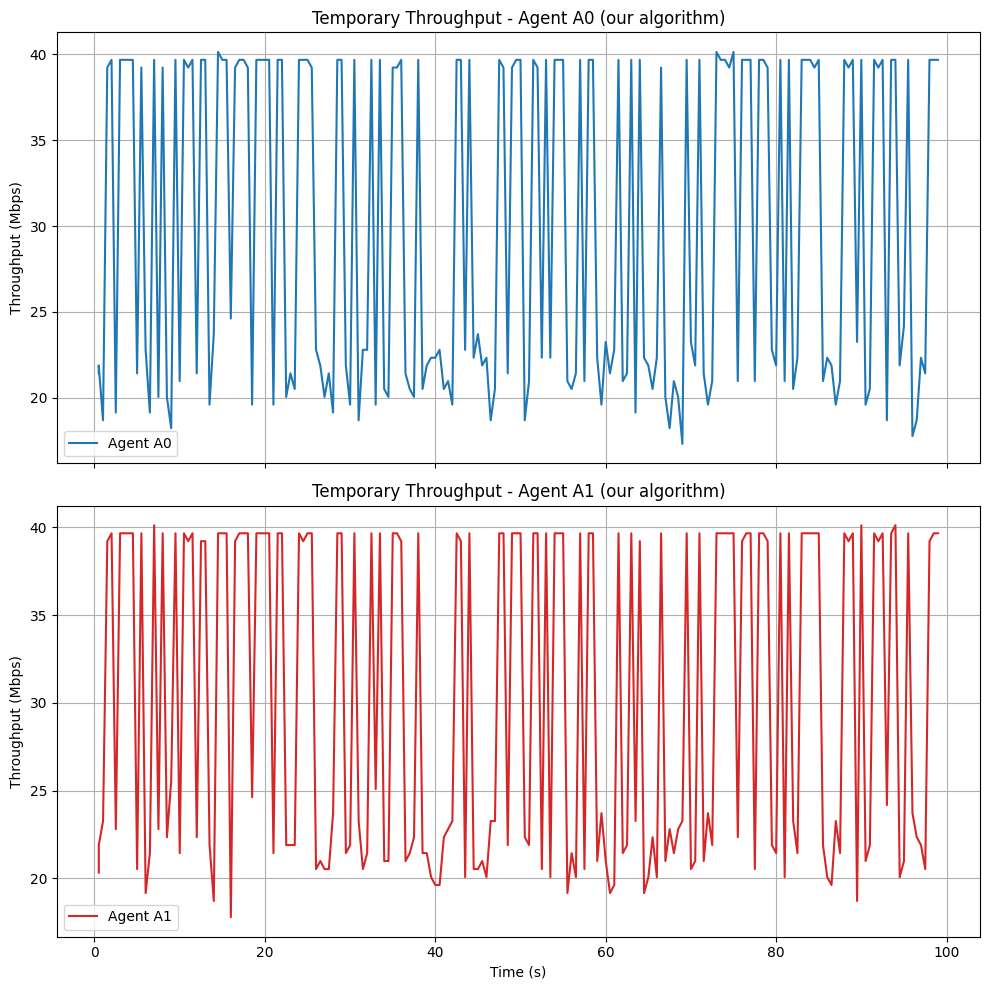

In [ ]:
# (response to exercise 5)

# PLOTTING OUR ALGORITHM

# Paths of the files
filename_agent1 = "drive/Shareddrives/MLNETWORKS/LABS/LAB1/output/logs_output_AAX-LAB1-AGENTS-ex5_A0_A.txt"
filename_agent2 = "drive/Shareddrives/MLNETWORKS/LABS/LAB1/output/logs_output_AAX-LAB1-AGENTS-ex5_A1_B.txt"

# Reading files
with open(filename_agent1, 'r') as f:
    log1 = f.read()
with open(filename_agent2, 'r') as f:
    log2 = f.read()

# Pattern
pattern = re.compile(
    r'(?P<time>\d+\.\d+);(?P<agent>A\d);C03;.*?Average throughput = (?P<throughput>[\d.]+) Mbps',
    re.DOTALL
)

# Extracting data
data1 = pattern.findall(log1)
data2 = pattern.findall(log2)

# Creating DataFrames with time and throughput
df1 = pd.DataFrame(data1, columns=['time', 'agent', 'throughput'])
df2 = pd.DataFrame(data2, columns=['time', 'agent', 'throughput'])

# Joining data
df = pd.concat([df1, df2], ignore_index=True)

# Converting types
df[['time', 'throughput']] = df[['time', 'throughput']].astype(float)

# We extract the throughput means (to use them later)
our_means = df.groupby('agent')['throughput'].mean().reindex(['A0', 'A1']).values

# Plotting different APs with different colors using subplots
agents = df['agent'].unique()
colors = ['tab:blue', 'tab:red']

fig, axes = plt.subplots(len(agents), 1, figsize=(10, 5 * len(agents)), sharex=True)

if len(agents) == 1:
    axes = [axes]

for ax, ap, color in zip(axes, agents, colors):
    grp = df[df['agent'] == ap]
    ax.plot(grp['time'], grp['throughput'], label=f'Agent {ap}', color=color)
    ax.set_title(f"Temporary Throughput - Agent {ap} (our algorithm)")
    ax.set_ylabel("Throughput (Mbps)")
    ax.grid(True)
    ax.legend()

axes[-1].set_xlabel("Time (s)")
plt.tight_layout()
plt.show()

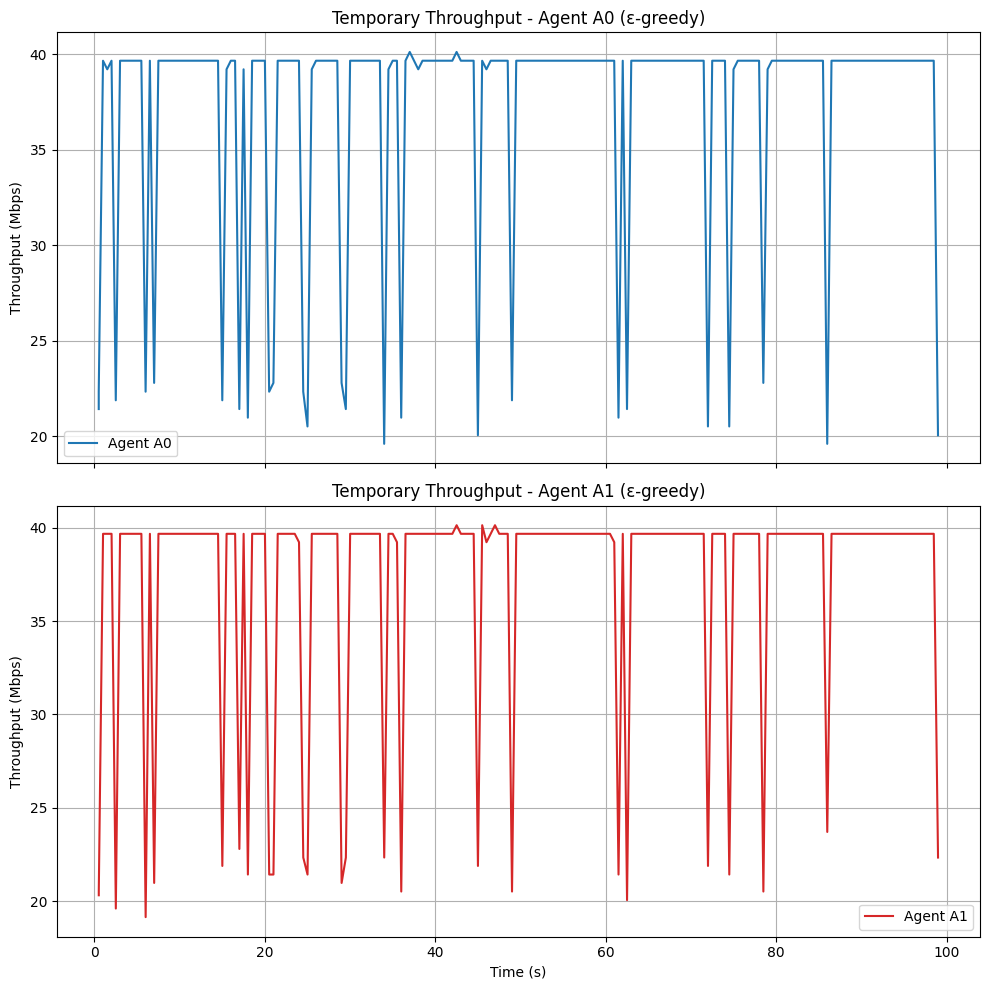

In [ ]:
# PLOTTING E-GREEDY

# Paths of the files
filename_agent1 = "drive/Shareddrives/MLNETWORKS/LABS/LAB1/output/logs_output_AAX-LAB1-EGREEDY-ex3_A0_A.txt"
filename_agent2 = "drive/Shareddrives/MLNETWORKS/LABS/LAB1/output/logs_output_AAX-LAB1-EGREEDY-ex3_A1_B.txt"

# Reading files
with open(filename_agent1, 'r') as f:
    log1 = f.read()
with open(filename_agent2, 'r') as f:
    log2 = f.read()

# Pattern
pattern = re.compile(
    r'(?P<time>\d+\.\d+);(?P<agent>A\d);C03;.*?Average throughput = (?P<throughput>[\d.]+) Mbps',
    re.DOTALL
)

# Extracting data
data1 = pattern.findall(log1)
data2 = pattern.findall(log2)

# Creating DataFrames with time and throughput
df1 = pd.DataFrame(data1, columns=['time', 'agent', 'throughput'])
df2 = pd.DataFrame(data2, columns=['time', 'agent', 'throughput'])

# Joining data
df = pd.concat([df1, df2], ignore_index=True)

# Converting types
df[['time', 'throughput']] = df[['time', 'throughput']].astype(float)

# We extract the throughput means (to use them later)
egreedy_means = df.groupby('agent')['throughput'].mean().reindex(['A0', 'A1']).values

# Plotting different APs with different colors using subplots
agents = df['agent'].unique()
colors = ['tab:blue', 'tab:red']

fig, axes = plt.subplots(len(agents), 1, figsize=(10, 5 * len(agents)), sharex=True)

if len(agents) == 1:
    axes = [axes]

for ax, ap, color in zip(axes, agents, colors):
    grp = df[df['agent'] == ap]
    ax.plot(grp['time'], grp['throughput'], label=f'Agent {ap}', color=color)
    ax.set_title(f"Temporary Throughput - Agent {ap} (ε-greedy)")
    ax.set_ylabel("Throughput (Mbps)")
    ax.grid(True)
    ax.legend()

axes[-1].set_xlabel("Time (s)")
plt.tight_layout()
plt.show()

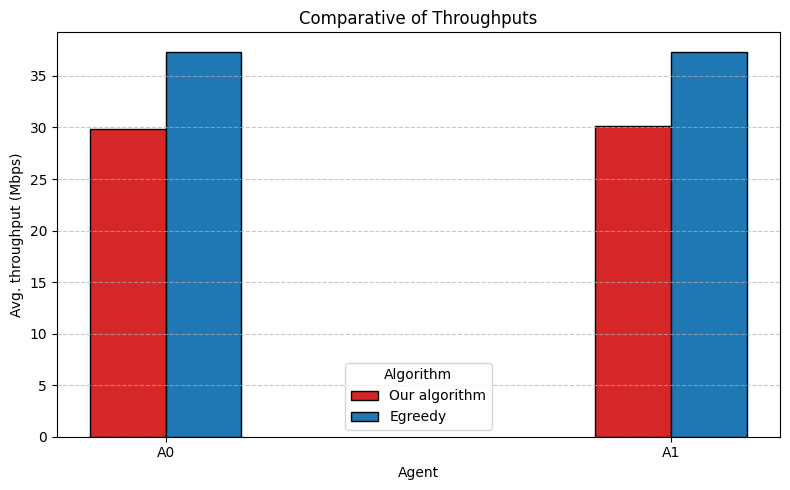

In [ ]:
# Creating array of data (rows = algorithms, columns = agents)
data = np.array([
    our_means,
    egreedy_means
])

# Algorithms and agents
experiments = ['Our algorithm', 'Egreedy']
agents = ['A0', 'A1']
colors = ['tab:red', 'tab:blue']

# We define the position and the width of the bars
x = np.arange(len(agents))
width = 0.15

# We plot the throughput
fig, ax = plt.subplots(figsize=(8, 5))

for i in range(len(experiments)):
    ax.bar(
        x + i * width,
        data[i, :],
        width=width,
        label=experiments[i],
        color=colors[i],
        edgecolor='black'
    )

ax.set_xlabel('Agent')
ax.set_ylabel('Avg. throughput (Mbps)')
ax.set_title('Comparative of Throughputs')
ax.set_xticks(x + width / 2)
ax.set_xticklabels(agents)
ax.grid(axis='y', linestyle='--', alpha=0.7)
ax.legend(title='Algorithm')

plt.tight_layout()
plt.show()

Throughput ranges mainly between 20 and 40 Mbps on both implementations, with significant peaks and dips. The e-greedy algorithm offers greater stability, while our algorithm has more sudden drops than the other. This may suggest that our algorithm explores aggressively, causing temporary performance losses. Furthermore, our algorithm has a lower average value than e-greedy, due to the number of sudden drops that our algorithm experiences. While our implementation has an average of 30 Mbps, the e-greedy algorithm has an average of more than 35 Mbps.

### **Exercise 6:**

Now, modify the "input_nodes.csv" and the input agent files (`agents_egreedy.csv` and `agents_ml4net.csv`) to add a third BSS, which must use the same configuration as the other BSSs but whose AP and STA must be placed at (10,0,0) m and (10,4,0) m, respectively. In the agents file, you will also have to add a third column so that the third BSS gets an agent enrolled.

Run N=5 simulations (using different random seeds) for each action-selection strategy and plot the average throughput obtained by each BSS across the different simulations for each approach.

In [ ]:
# We create an array that will help us for the last plot
means_all = []

Throughput obtained with e-greedy:

In [ ]:
# DEFINE SIMULATION ARGUMENTS (WITH AGENTS FOR MONITORING PERFORMANCE)

# Path of the file that describes the Wi-Fi nodes
INPUT_FILE_NODES='../input/input_nodes_ex_6.csv'

# Path of the file that describes the agents associated with nodes
INPUT_FILE_AGENTS='../input/agents_egreedy_ex_6.csv'

# Path of the file where output logs are going to be written
OUTPUT_FILE_LOGS='../output/logs_output_AAX_EGREEDY_ex6.txt'

# Path of the file where output logs are going to be written
SIMULATION_CODE='AAX-LAB1-AGENTS-EGREEDY-ex6'

In [ ]:
!cd $mypath/main; ./komondor_main $INPUT_FILE_NODES $INPUT_FILE_AGENTS $OUTPUT_FILE_LOGS $SIMULATION_CODE $FLAG_SAVE_NODE_LOGS $FLAG_SAVE_AGENT_LOGS $FLAG_PRINT_SYSTEM_LOGS $FLAG_PRINT_NODE_LOGS $FLAG_PRINT_AGENT_LOGS $SIM_TIME $SEED


*************************************************************************************
 KOMONDOR Wireless Network Simulator
 Copyright (C) 2017-2022, and GNU GPL'd, by Sergio Barrachina & Francesc Wilhelmi
  - GitHub repository: https://github.com/wn-upf/Komondor
*************************************************************************************


 FULL configuration entered per console (AGENTS ENABLED).
 Komondor input configuration:
  - nodes_input_filename: ../input/input_nodes_ex_6.csv
  - agents_enabled: 1
  - agents_input_filename: ../input/agents_egreedy_ex_6.csv
  - script_output_filename: ../output/logs_output_AAX_EGREEDY_ex6.txt
  - simulation_code: AAX-LAB1-AGENTS-EGREEDY-ex6
  - save_node_logs: 0
  - print_system_logs: 1
  - print_node_logs: 1
  - sim_time: 100.000000 s
  - seed: 7

 Creating output files
  - Simulation output file 'output/logs_console_AAX-LAB1-AGENTS-EGREEDY-ex6.txt' created!

 Reading system configuration file '../config_models'...
  - System environmen

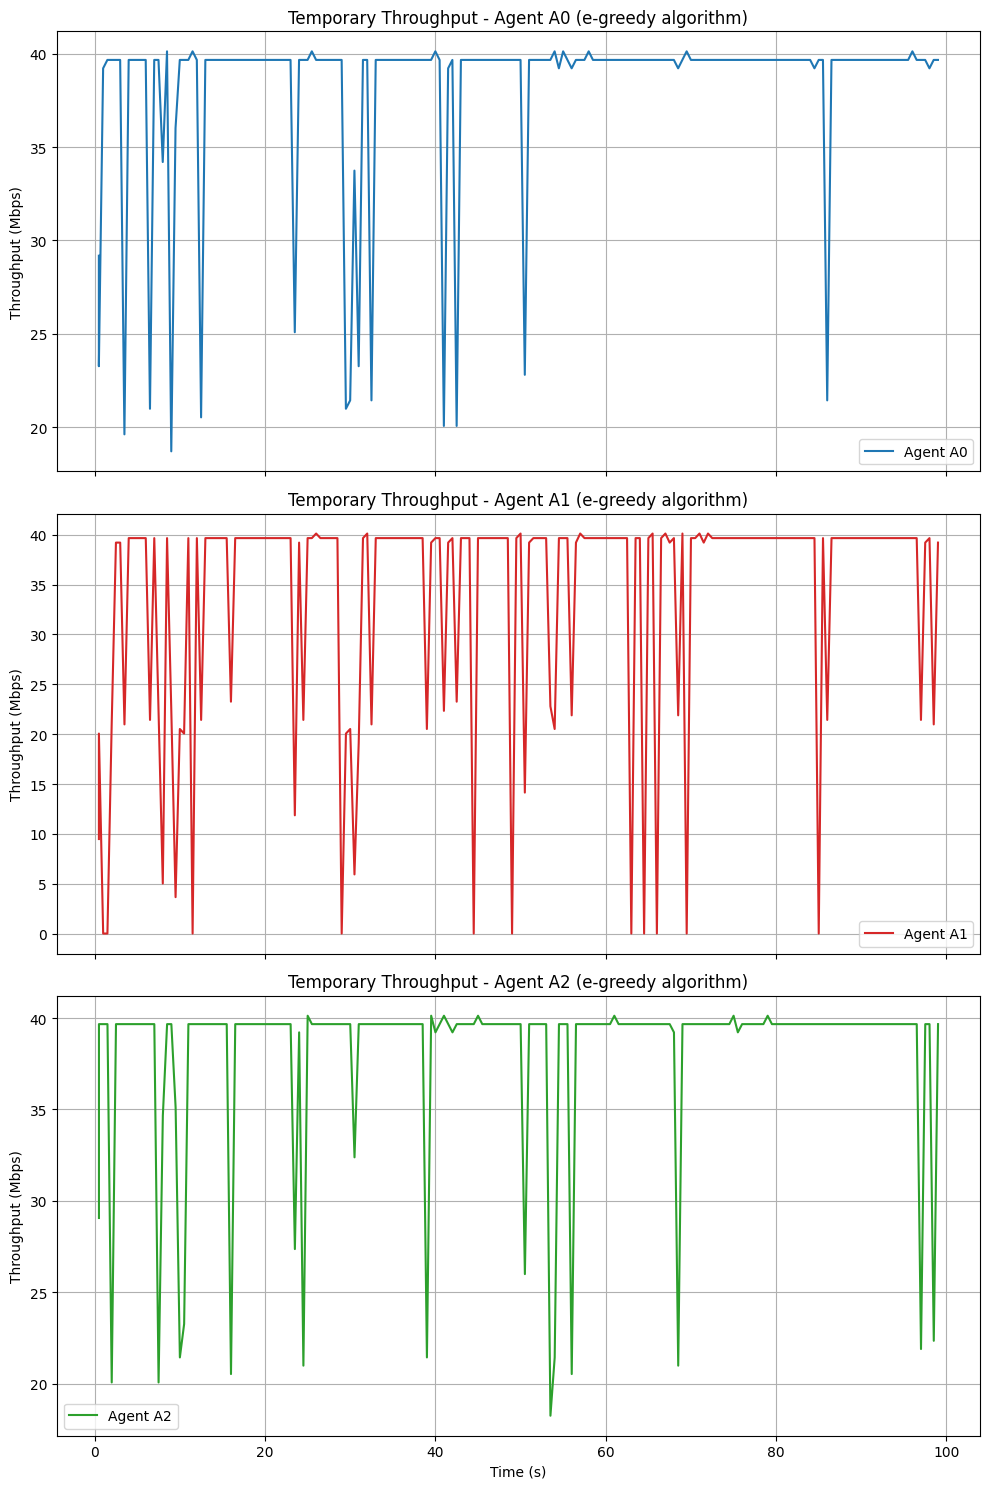

In [ ]:
# PLOTTING E-GREEDY

import re
import pandas as pd
import matplotlib.pyplot as plt

# Paths of the files
filename_agent1 = "drive/Shareddrives/MLNETWORKS/LABS/LAB1/output/logs_output_AAX-LAB1-AGENTS-EGREEDY-ex6_A0_A.txt"
filename_agent2 = "drive/Shareddrives/MLNETWORKS/LABS/LAB1/output/logs_output_AAX-LAB1-AGENTS-EGREEDY-ex6_A1_B.txt"
filename_agent3 = "drive/Shareddrives/MLNETWORKS/LABS/LAB1/output/logs_output_AAX-LAB1-AGENTS-EGREEDY-ex6_A2_C.txt"

# Reading files
with open(filename_agent1, 'r') as f:
    log1 = f.read()
with open(filename_agent2, 'r') as f:
    log2 = f.read()
with open(filename_agent3, 'r') as f:
    log3 = f.read()

# Pattern
pattern = re.compile(
    r'(?P<time>\d+\.\d+);(?P<agent>A\d);C\d\d;.*?Average throughput = (?P<throughput>[\d.]+) Mbps',
    re.DOTALL
)

# Extracting data
data1 = pattern.findall(log1)
data2 = pattern.findall(log2)
data3 = pattern.findall(log3)

# Creating DataFrames with time and throughput
df1 = pd.DataFrame(data1, columns=['time', 'agent', 'throughput'])
df2 = pd.DataFrame(data2, columns=['time', 'agent', 'throughput'])
df3 = pd.DataFrame(data3, columns=['time', 'agent', 'throughput'])

# Joining data
df = pd.concat([df1, df2, df3], ignore_index=True)

# Converting types
df[['time', 'throughput']] = df[['time', 'throughput']].astype(float)

# Plotting different APs with different colors using subplots
agents = df['agent'].unique()
colors = ['tab:blue', 'tab:red', 'tab:green']

fig, axes = plt.subplots(len(agents), 1, figsize=(10, 5 * len(agents)), sharex=True)

if len(agents) == 1:
    axes = [axes]

for ax, ap, color in zip(axes, agents, colors):
    grp = df[df['agent'] == ap]
    ax.plot(grp['time'], grp['throughput'], label=f'Agent {ap}', color=color)
    ax.set_title(f"Temporary Throughput - Agent {ap} (e-greedy algorithm)")
    ax.set_ylabel("Throughput (Mbps)")
    ax.grid(True)
    ax.legend()

axes[-1].set_xlabel("Time (s)")
plt.tight_layout()
plt.show()

mean_throughput_series = df.groupby('agent')['throughput'].mean()

mean_throughput_dict = mean_throughput_series.to_dict()

agent_order = ['A0', 'A1', 'A2']
means = [mean_throughput_dict[agent] for agent in agent_order]

means_all.append(means)

Throughput obtained with Thompson:

In [ ]:
# DEFINE SIMULATION ARGUMENTS (WITH AGENTS FOR MONITORING PERFORMANCE)

# Path of the file that describes the Wi-Fi nodes
INPUT_FILE_NODES='../input/input_nodes_ex_6.csv'

# Path of the file that describes the agents associated with nodes
INPUT_FILE_AGENTS='../input/agents_thompson_ex_6.csv'

# Path of the file where output logs are going to be written
OUTPUT_FILE_LOGS='../output/logs_output_AAX_THOMPSON_ex6.txt'

# Path of the file where output logs are going to be written
SIMULATION_CODE='AAX-LAB1-AGENTS-THOMPSON-ex6'

In [ ]:
!cd $mypath/main; ./komondor_main $INPUT_FILE_NODES $INPUT_FILE_AGENTS $OUTPUT_FILE_LOGS $SIMULATION_CODE $FLAG_SAVE_NODE_LOGS $FLAG_SAVE_AGENT_LOGS $FLAG_PRINT_SYSTEM_LOGS $FLAG_PRINT_NODE_LOGS $FLAG_PRINT_AGENT_LOGS $SIM_TIME $SEED


*************************************************************************************
 KOMONDOR Wireless Network Simulator
 Copyright (C) 2017-2022, and GNU GPL'd, by Sergio Barrachina & Francesc Wilhelmi
  - GitHub repository: https://github.com/wn-upf/Komondor
*************************************************************************************


 FULL configuration entered per console (AGENTS ENABLED).
 Komondor input configuration:
  - nodes_input_filename: ../input/input_nodes_ex_6.csv
  - agents_enabled: 1
  - agents_input_filename: ../input/agents_thompson_ex_6.csv
  - script_output_filename: ../output/logs_output_AAX_THOMPSON_ex6.txt
  - simulation_code: AAX-LAB1-AGENTS-THOMPSON-ex6
  - save_node_logs: 0
  - print_system_logs: 1
  - print_node_logs: 1
  - sim_time: 100.000000 s
  - seed: 7

 Creating output files
  - Simulation output file 'output/logs_console_AAX-LAB1-AGENTS-THOMPSON-ex6.txt' created!

 Reading system configuration file '../config_models'...
  - System enviro

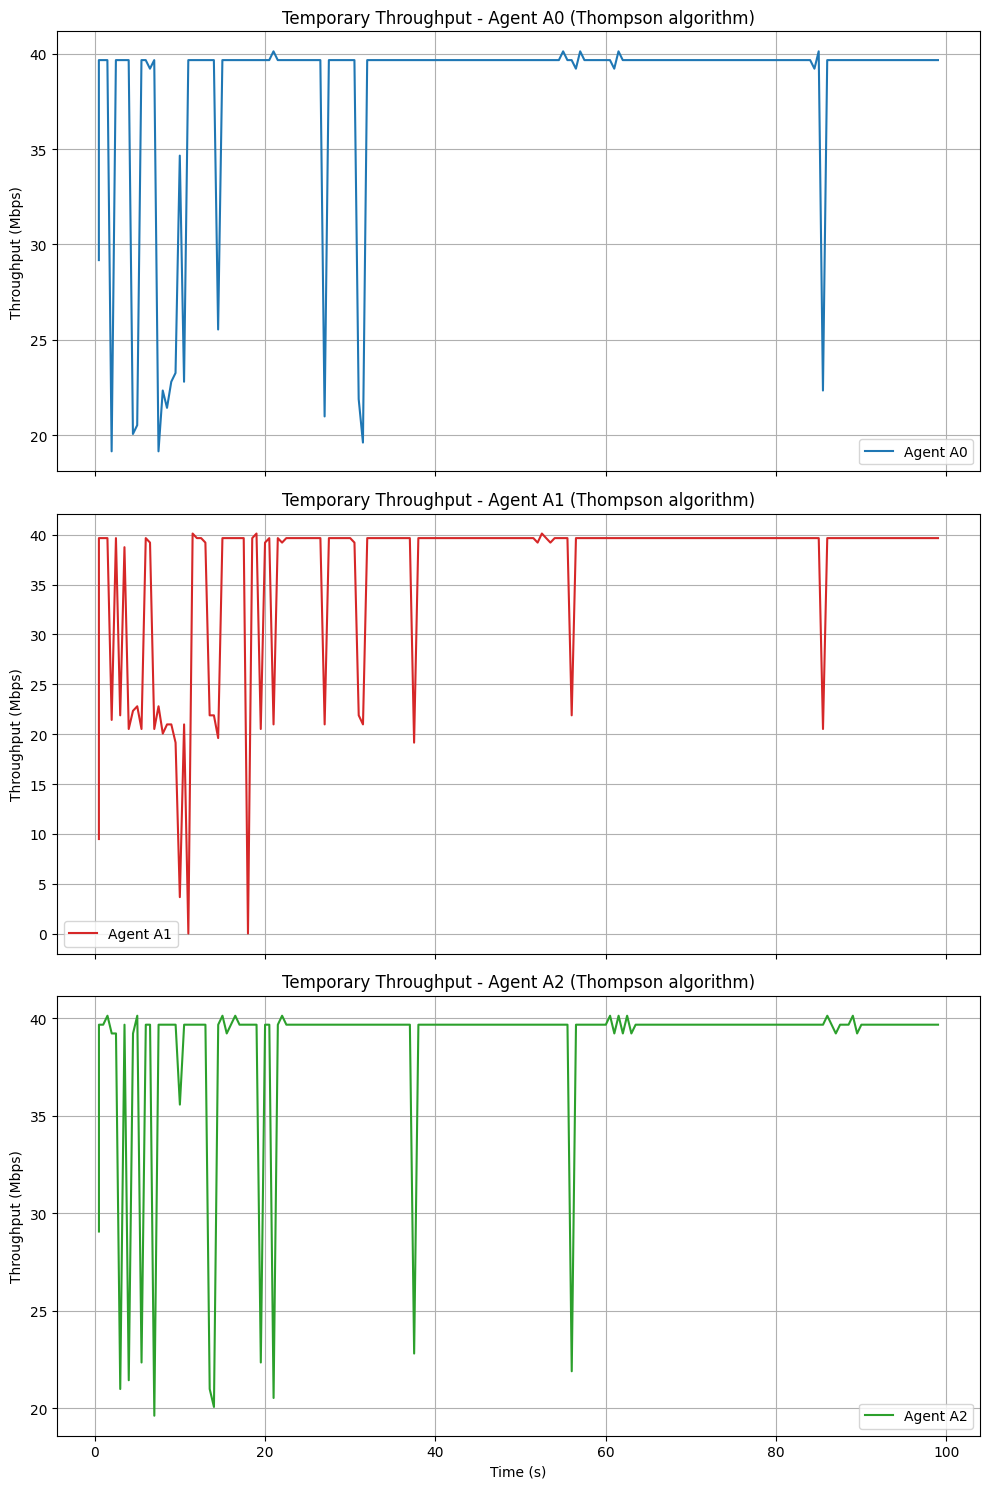

In [ ]:
# PLOTTING Thompson

import re
import pandas as pd
import matplotlib.pyplot as plt

# Paths of the files
filename_agent1 = "drive/Shareddrives/MLNETWORKS/LABS/LAB1/output/logs_output_AAX-LAB1-AGENTS-THOMPSON-ex6_A0_A.txt"
filename_agent2 = "drive/Shareddrives/MLNETWORKS/LABS/LAB1/output/logs_output_AAX-LAB1-AGENTS-THOMPSON-ex6_A1_B.txt"
filename_agent3 = "drive/Shareddrives/MLNETWORKS/LABS/LAB1/output/logs_output_AAX-LAB1-AGENTS-THOMPSON-ex6_A2_C.txt"

# Reading files
with open(filename_agent1, 'r') as f:
    log1 = f.read()
with open(filename_agent2, 'r') as f:
    log2 = f.read()
with open(filename_agent3, 'r') as f:
    log3 = f.read()

# Pattern
pattern = re.compile(
    r'(?P<time>\d+\.\d+);(?P<agent>A\d);C\d\d;.*?Average throughput = (?P<throughput>[\d.]+) Mbps',
    re.DOTALL
)

# Extracting data
data1 = pattern.findall(log1)
data2 = pattern.findall(log2)
data3 = pattern.findall(log3)

# Creating DataFrames with time and throughput
df1 = pd.DataFrame(data1, columns=['time', 'agent', 'throughput'])
df2 = pd.DataFrame(data2, columns=['time', 'agent', 'throughput'])
df3 = pd.DataFrame(data3, columns=['time', 'agent', 'throughput'])

# Joining data
df = pd.concat([df1, df2, df3], ignore_index=True)

# Converting types
df[['time', 'throughput']] = df[['time', 'throughput']].astype(float)

# Plotting different APs with different colors using subplots
agents = df['agent'].unique()
colors = ['tab:blue', 'tab:red', 'tab:green']

fig, axes = plt.subplots(len(agents), 1, figsize=(10, 5 * len(agents)), sharex=True)

if len(agents) == 1:
    axes = [axes]

for ax, ap, color in zip(axes, agents, colors):
    grp = df[df['agent'] == ap]
    ax.plot(grp['time'], grp['throughput'], label=f'Agent {ap}', color=color)
    ax.set_title(f"Temporary Throughput - Agent {ap} (Thompson algorithm)")
    ax.set_ylabel("Throughput (Mbps)")
    ax.grid(True)
    ax.legend()

axes[-1].set_xlabel("Time (s)")
plt.tight_layout()
plt.show()

mean_throughput_series = df.groupby('agent')['throughput'].mean()

mean_throughput_dict = mean_throughput_series.to_dict()

agent_order = ['A0', 'A1', 'A2']
means = [mean_throughput_dict[agent] for agent in agent_order]

means_all.append(means)

Throughput obtained with UCB:

In [ ]:
# DEFINE SIMULATION ARGUMENTS (WITH AGENTS FOR MONITORING PERFORMANCE)

# Path of the file that describes the Wi-Fi nodes
INPUT_FILE_NODES='../input/input_nodes_ex_6.csv'

# Path of the file that describes the agents associated with nodes
INPUT_FILE_AGENTS='../input/agents_ucb_ex_6.csv'

# Path of the file where output logs are going to be written
OUTPUT_FILE_LOGS='../output/logs_output_AAX_UCB_ex6.txt'

# Path of the file where output logs are going to be written
SIMULATION_CODE='AAX-LAB1-AGENTS-UCB-ex6'

In [ ]:
!cd $mypath/main; ./komondor_main $INPUT_FILE_NODES $INPUT_FILE_AGENTS $OUTPUT_FILE_LOGS $SIMULATION_CODE $FLAG_SAVE_NODE_LOGS $FLAG_SAVE_AGENT_LOGS $FLAG_PRINT_SYSTEM_LOGS $FLAG_PRINT_NODE_LOGS $FLAG_PRINT_AGENT_LOGS $SIM_TIME $SEED


*************************************************************************************
 KOMONDOR Wireless Network Simulator
 Copyright (C) 2017-2022, and GNU GPL'd, by Sergio Barrachina & Francesc Wilhelmi
  - GitHub repository: https://github.com/wn-upf/Komondor
*************************************************************************************


 FULL configuration entered per console (AGENTS ENABLED).
 Komondor input configuration:
  - nodes_input_filename: ../input/input_nodes_ex_6.csv
  - agents_enabled: 1
  - agents_input_filename: ../input/agents_ucb_ex_6.csv
  - script_output_filename: ../output/logs_output_AAX_UCB_ex6.txt
  - simulation_code: AAX-LAB1-AGENTS-UCB-ex6
  - save_node_logs: 0
  - print_system_logs: 1
  - print_node_logs: 1
  - sim_time: 100.000000 s
  - seed: 7

 Creating output files
  - Simulation output file 'output/logs_console_AAX-LAB1-AGENTS-UCB-ex6.txt' created!

 Reading system configuration file '../config_models'...
  - System environment properly set!


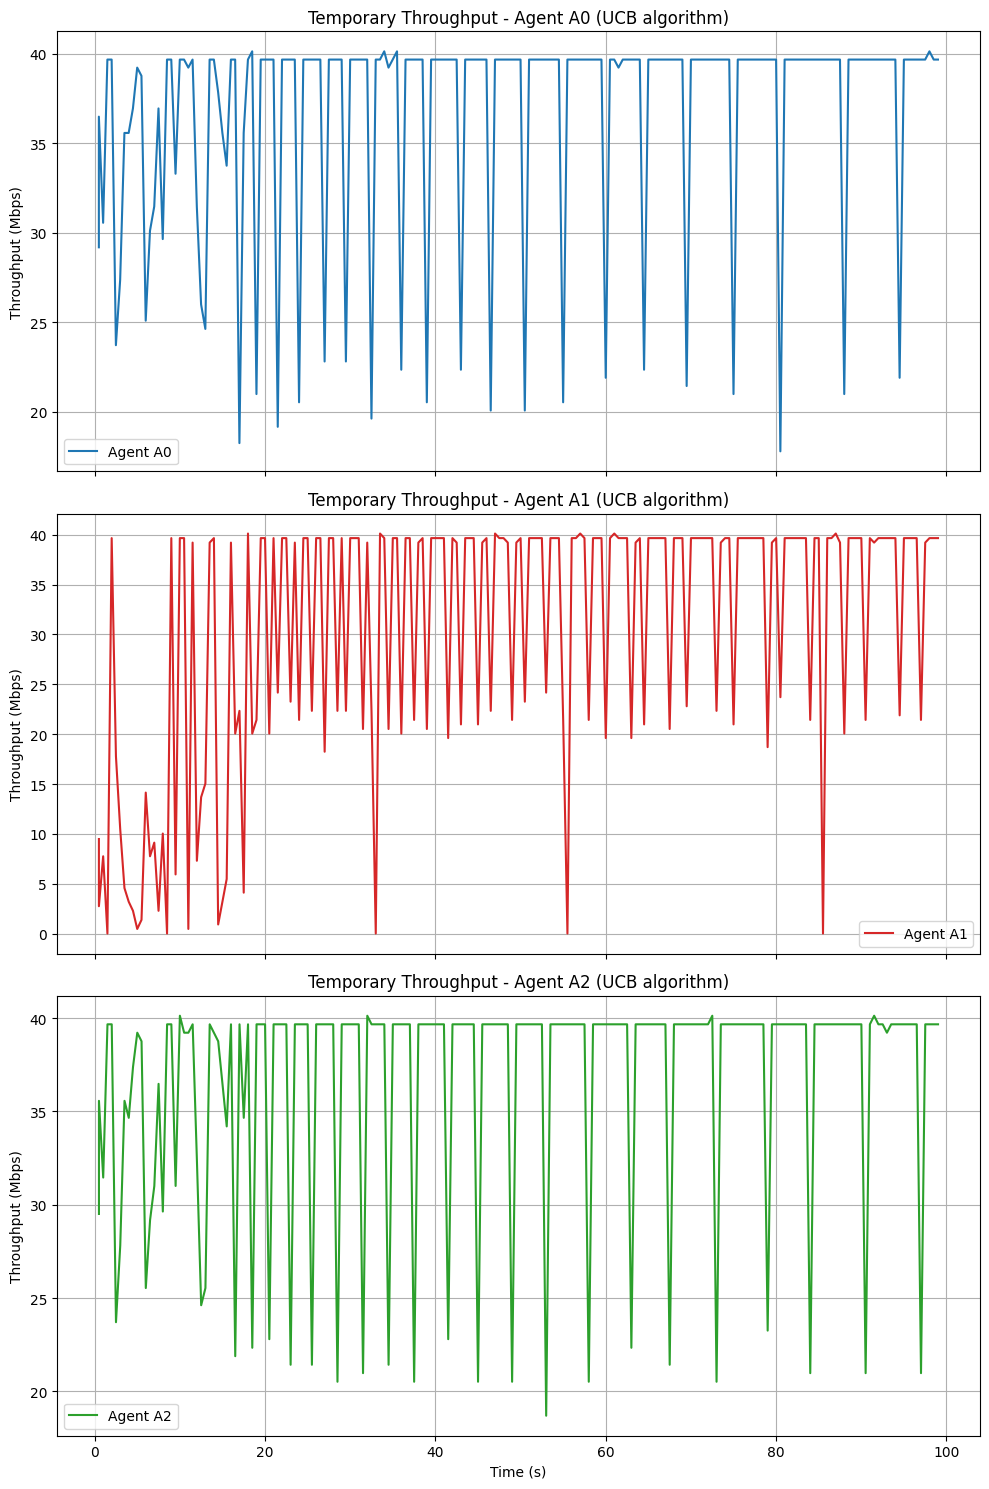

In [ ]:
# PLOTTING UCB

import re
import pandas as pd
import matplotlib.pyplot as plt

# Paths of the files
filename_agent1 = "drive/Shareddrives/MLNETWORKS/LABS/LAB1/output/logs_output_AAX-LAB1-AGENTS-UCB-ex6_A0_A.txt"
filename_agent2 = "drive/Shareddrives/MLNETWORKS/LABS/LAB1/output/logs_output_AAX-LAB1-AGENTS-UCB-ex6_A1_B.txt"
filename_agent3 = "drive/Shareddrives/MLNETWORKS/LABS/LAB1/output/logs_output_AAX-LAB1-AGENTS-UCB-ex6_A2_C.txt"

# Reading files
with open(filename_agent1, 'r') as f:
    log1 = f.read()
with open(filename_agent2, 'r') as f:
    log2 = f.read()
with open(filename_agent3, 'r') as f:
    log3 = f.read()

# Pattern
pattern = re.compile(
    r'(?P<time>\d+\.\d+);(?P<agent>A\d);C\d\d;.*?Average throughput = (?P<throughput>[\d.]+) Mbps',
    re.DOTALL
)

# Extracting data
data1 = pattern.findall(log1)
data2 = pattern.findall(log2)
data3 = pattern.findall(log3)

# Creating DataFrames with time and throughput
df1 = pd.DataFrame(data1, columns=['time', 'agent', 'throughput'])
df2 = pd.DataFrame(data2, columns=['time', 'agent', 'throughput'])
df3 = pd.DataFrame(data3, columns=['time', 'agent', 'throughput'])

# Joining data
df = pd.concat([df1, df2, df3], ignore_index=True)

# Converting types
df[['time', 'throughput']] = df[['time', 'throughput']].astype(float)

# Plotting different APs with different colors using subplots
agents = df['agent'].unique()
colors = ['tab:blue', 'tab:red', 'tab:green']

fig, axes = plt.subplots(len(agents), 1, figsize=(10, 5 * len(agents)), sharex=True)

if len(agents) == 1:
    axes = [axes]

for ax, ap, color in zip(axes, agents, colors):
    grp = df[df['agent'] == ap]
    ax.plot(grp['time'], grp['throughput'], label=f'Agent {ap}', color=color)
    ax.set_title(f"Temporary Throughput - Agent {ap} (UCB algorithm)")
    ax.set_ylabel("Throughput (Mbps)")
    ax.grid(True)
    ax.legend()

axes[-1].set_xlabel("Time (s)")
plt.tight_layout()
plt.show()

mean_throughput_series = df.groupby('agent')['throughput'].mean()

mean_throughput_dict = mean_throughput_series.to_dict()

agent_order = ['A0', 'A1', 'A2']
means = [mean_throughput_dict[agent] for agent in agent_order]

means_all.append(means)

Throughput obtained with Sequentially:

In [ ]:
# DEFINE SIMULATION ARGUMENTS (WITH AGENTS FOR MONITORING PERFORMANCE)

# Path of the file that describes the Wi-Fi nodes
INPUT_FILE_NODES='../input/input_nodes_ex_6.csv'

# Path of the file that describes the agents associated with nodes
INPUT_FILE_AGENTS='../input/agents_sequentially_ex_6.csv'

# Path of the file where output logs are going to be written
OUTPUT_FILE_LOGS='../output/logs_output_AAX_SEQUENTIALLY_ex6.txt'

# Path of the file where output logs are going to be written
SIMULATION_CODE='AAX-LAB1-AGENTS-SEQUENTIALLY-ex6'

In [ ]:
!cd $mypath/main; ./komondor_main $INPUT_FILE_NODES $INPUT_FILE_AGENTS $OUTPUT_FILE_LOGS $SIMULATION_CODE $FLAG_SAVE_NODE_LOGS $FLAG_SAVE_AGENT_LOGS $FLAG_PRINT_SYSTEM_LOGS $FLAG_PRINT_NODE_LOGS $FLAG_PRINT_AGENT_LOGS $SIM_TIME $SEED


*************************************************************************************
 KOMONDOR Wireless Network Simulator
 Copyright (C) 2017-2022, and GNU GPL'd, by Sergio Barrachina & Francesc Wilhelmi
  - GitHub repository: https://github.com/wn-upf/Komondor
*************************************************************************************


 FULL configuration entered per console (AGENTS ENABLED).
 Komondor input configuration:
  - nodes_input_filename: ../input/input_nodes_ex_6.csv
  - agents_enabled: 1
  - agents_input_filename: ../input/agents_sequentially_ex_6.csv
  - script_output_filename: ../output/logs_output_AAX_SEQUENTIALLY_ex6.txt
  - simulation_code: AAX-LAB1-AGENTS-SEQUENTIALLY-ex6
  - save_node_logs: 0
  - print_system_logs: 1
  - print_node_logs: 1
  - sim_time: 100.000000 s
  - seed: 7

 Creating output files
  - Simulation output file 'output/logs_console_AAX-LAB1-AGENTS-SEQUENTIALLY-ex6.txt' created!

 Reading system configuration file '../config_models'...
 

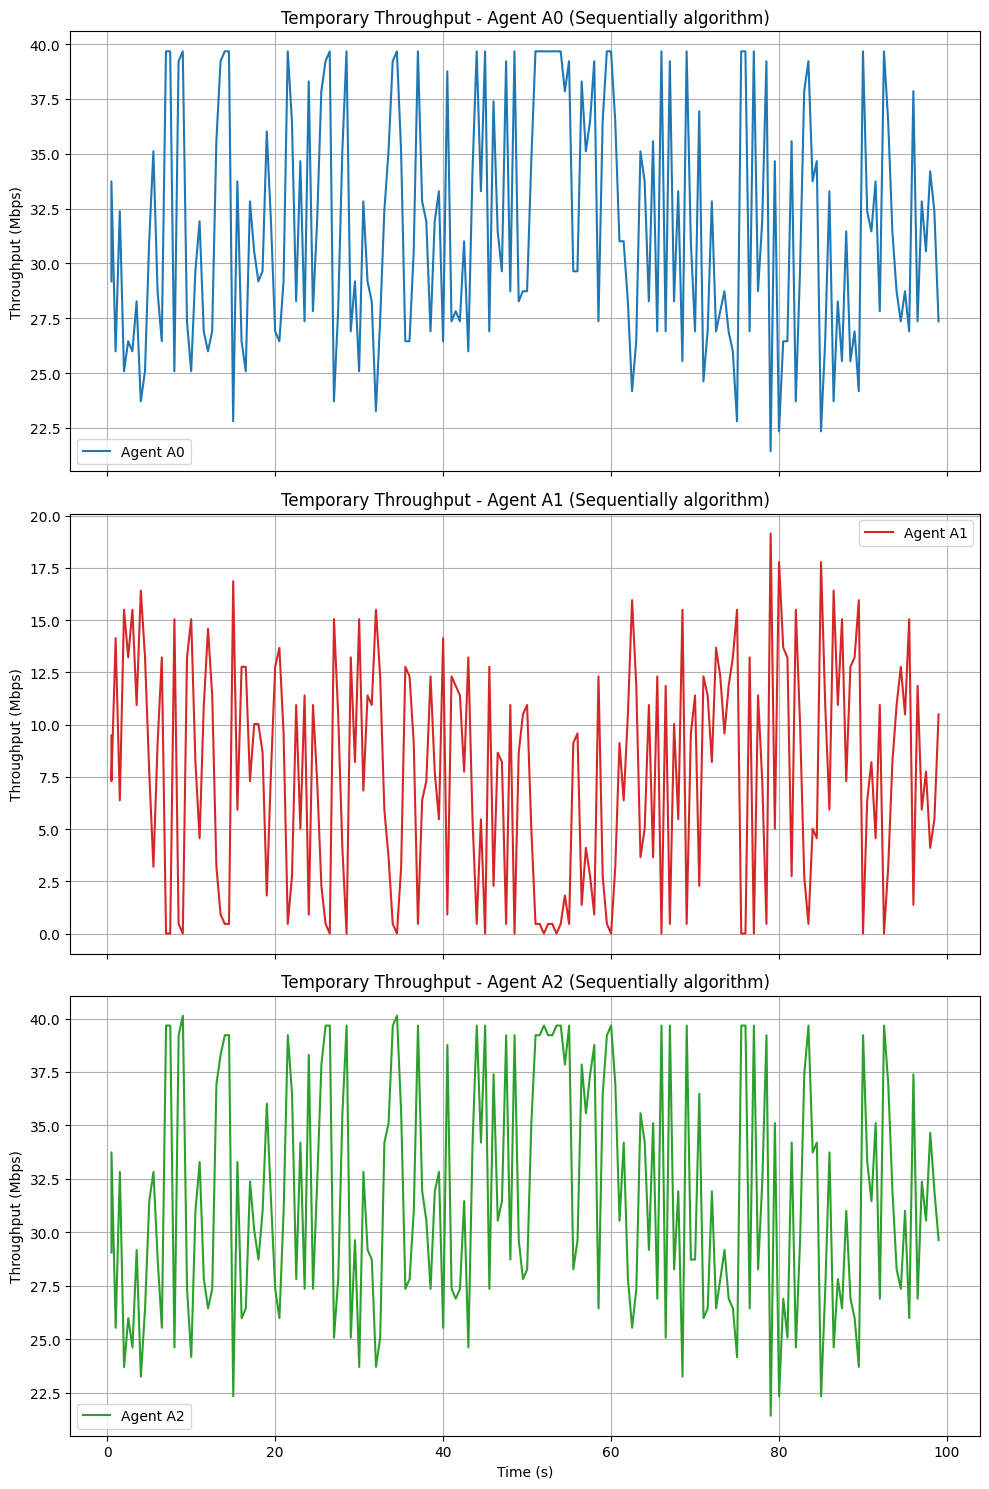

In [ ]:
# PLOTTING Sequentially

import re
import pandas as pd
import matplotlib.pyplot as plt

# Paths of the files
filename_agent1 = "drive/Shareddrives/MLNETWORKS/LABS/LAB1/output/logs_output_AAX-LAB1-AGENTS-SEQUENTIALLY-ex6_A0_A.txt"
filename_agent2 = "drive/Shareddrives/MLNETWORKS/LABS/LAB1/output/logs_output_AAX-LAB1-AGENTS-SEQUENTIALLY-ex6_A1_B.txt"
filename_agent3 = "drive/Shareddrives/MLNETWORKS/LABS/LAB1/output/logs_output_AAX-LAB1-AGENTS-SEQUENTIALLY-ex6_A2_C.txt"

# Reading files
with open(filename_agent1, 'r') as f:
    log1 = f.read()
with open(filename_agent2, 'r') as f:
    log2 = f.read()
with open(filename_agent3, 'r') as f:
    log3 = f.read()

# Pattern
pattern = re.compile(
    r'(?P<time>\d+\.\d+);(?P<agent>A\d);C\d\d;.*?Average throughput = (?P<throughput>[\d.]+) Mbps',
    re.DOTALL
)

# Extracting data
data1 = pattern.findall(log1)
data2 = pattern.findall(log2)
data3 = pattern.findall(log3)

# Creating DataFrames with time and throughput
df1 = pd.DataFrame(data1, columns=['time', 'agent', 'throughput'])
df2 = pd.DataFrame(data2, columns=['time', 'agent', 'throughput'])
df3 = pd.DataFrame(data3, columns=['time', 'agent', 'throughput'])

# Joining data
df = pd.concat([df1, df2, df3], ignore_index=True)

# Converting types
df[['time', 'throughput']] = df[['time', 'throughput']].astype(float)

# Plotting different APs with different colors using subplots
agents = df['agent'].unique()
colors = ['tab:blue', 'tab:red', 'tab:green']

fig, axes = plt.subplots(len(agents), 1, figsize=(10, 5 * len(agents)), sharex=True)

if len(agents) == 1:
    axes = [axes]

for ax, ap, color in zip(axes, agents, colors):
    grp = df[df['agent'] == ap]
    ax.plot(grp['time'], grp['throughput'], label=f'Agent {ap}', color=color)
    ax.set_title(f"Temporary Throughput - Agent {ap} (Sequentially algorithm)")
    ax.set_ylabel("Throughput (Mbps)")
    ax.grid(True)
    ax.legend()

axes[-1].set_xlabel("Time (s)")
plt.tight_layout()
plt.show()

mean_throughput_series = df.groupby('agent')['throughput'].mean()

mean_throughput_dict = mean_throughput_series.to_dict()

agent_order = ['A0', 'A1', 'A2']
means = [mean_throughput_dict[agent] for agent in agent_order]

means_all.append(means)

Throughput obtained with our algorithm:

In [ ]:
# DEFINE SIMULATION ARGUMENTS (WITH AGENTS FOR MONITORING PERFORMANCE)

# Path of the file that describes the Wi-Fi nodes
INPUT_FILE_NODES='../input/input_nodes_ex_6.csv'

# Path of the file that describes the agents associated with nodes
INPUT_FILE_AGENTS='../input/agents_ml4net_ex_6.csv'

# Path of the file where output logs are going to be written
OUTPUT_FILE_LOGS='../output/logs_output_AAX_ML4NET_ex6.txt'

# Path of the file where output logs are going to be written
SIMULATION_CODE='AAX-LAB1-AGENTS-ML4NET-ex6'

In [ ]:
!cd $mypath/main; ./komondor_main $INPUT_FILE_NODES $INPUT_FILE_AGENTS $OUTPUT_FILE_LOGS $SIMULATION_CODE $FLAG_SAVE_NODE_LOGS $FLAG_SAVE_AGENT_LOGS $FLAG_PRINT_SYSTEM_LOGS $FLAG_PRINT_NODE_LOGS $FLAG_PRINT_AGENT_LOGS $SIM_TIME $SEED


*************************************************************************************
 KOMONDOR Wireless Network Simulator
 Copyright (C) 2017-2022, and GNU GPL'd, by Sergio Barrachina & Francesc Wilhelmi
  - GitHub repository: https://github.com/wn-upf/Komondor
*************************************************************************************


 FULL configuration entered per console (AGENTS ENABLED).
 Komondor input configuration:
  - nodes_input_filename: ../input/input_nodes_ex_6.csv
  - agents_enabled: 1
  - agents_input_filename: ../input/agents_ml4net_ex_6.csv
  - script_output_filename: ../output/logs_output_AAX_ML4NET_ex6.txt
  - simulation_code: AAX-LAB1-AGENTS-ML4NET-ex6
  - save_node_logs: 0
  - print_system_logs: 1
  - print_node_logs: 1
  - sim_time: 100.000000 s
  - seed: 7

 Creating output files
  - Simulation output file 'output/logs_console_AAX-LAB1-AGENTS-ML4NET-ex6.txt' created!

 Reading system configuration file '../config_models'...
  - System environment pr

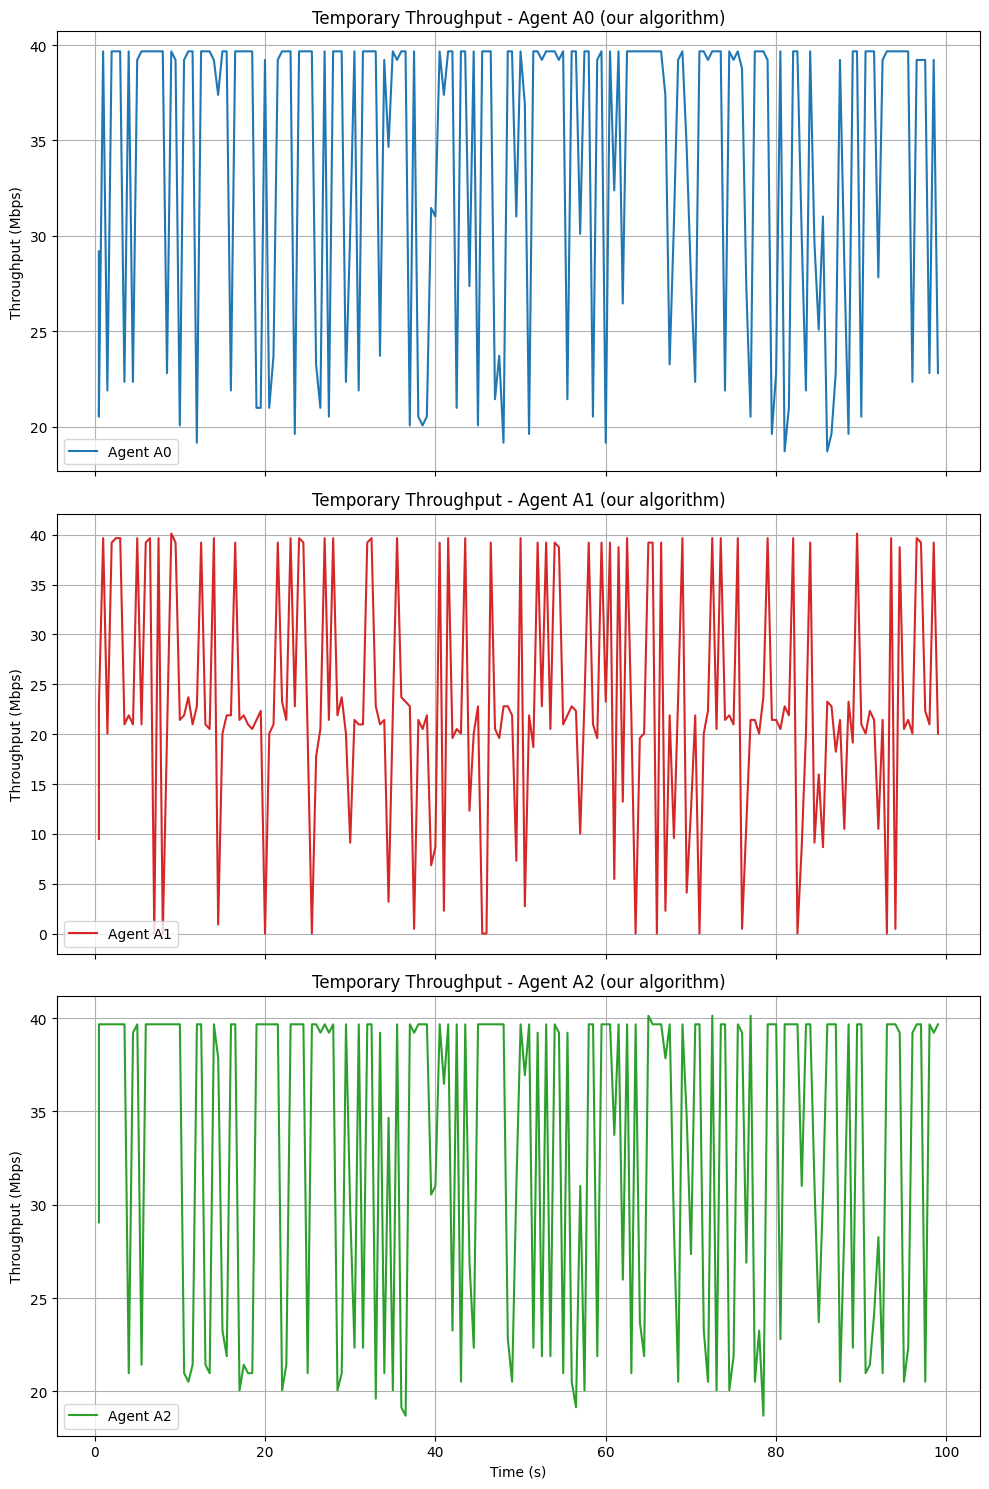

In [ ]:
# PLOTTING OUR ALGORITHM

import re
import pandas as pd
import matplotlib.pyplot as plt

# Paths of the files
filename_agent1 = "drive/Shareddrives/MLNETWORKS/LABS/LAB1/output/logs_output_AAX-LAB1-AGENTS-ML4NET-ex6_A0_A.txt"
filename_agent2 = "drive/Shareddrives/MLNETWORKS/LABS/LAB1/output/logs_output_AAX-LAB1-AGENTS-ML4NET-ex6_A1_B.txt"
filename_agent3 = "drive/Shareddrives/MLNETWORKS/LABS/LAB1/output/logs_output_AAX-LAB1-AGENTS-ML4NET-ex6_A2_C.txt"

# Reading files
with open(filename_agent1, 'r') as f:
    log1 = f.read()
with open(filename_agent2, 'r') as f:
    log2 = f.read()
with open(filename_agent3, 'r') as f:
    log3 = f.read()

# Pattern
pattern = re.compile(
    r'(?P<time>\d+\.\d+);(?P<agent>A\d);C\d\d;.*?Average throughput = (?P<throughput>[\d.]+) Mbps',
    re.DOTALL
)

# Extracting data
data1 = pattern.findall(log1)
data2 = pattern.findall(log2)
data3 = pattern.findall(log3)

# Creating DataFrames with time and throughput
df1 = pd.DataFrame(data1, columns=['time', 'agent', 'throughput'])
df2 = pd.DataFrame(data2, columns=['time', 'agent', 'throughput'])
df3 = pd.DataFrame(data3, columns=['time', 'agent', 'throughput'])

# Joining data
df = pd.concat([df1, df2, df3], ignore_index=True)

# Converting types
df[['time', 'throughput']] = df[['time', 'throughput']].astype(float)

# Plotting different APs with different colors using subplots
agents = df['agent'].unique()
colors = ['tab:blue', 'tab:red', 'tab:green']

fig, axes = plt.subplots(len(agents), 1, figsize=(10, 5 * len(agents)), sharex=True)

if len(agents) == 1:
    axes = [axes]

for ax, ap, color in zip(axes, agents, colors):
    grp = df[df['agent'] == ap]
    ax.plot(grp['time'], grp['throughput'], label=f'Agent {ap}', color=color)
    ax.set_title(f"Temporary Throughput - Agent {ap} (our algorithm)")
    ax.set_ylabel("Throughput (Mbps)")
    ax.grid(True)
    ax.legend()

axes[-1].set_xlabel("Time (s)")
plt.tight_layout()
plt.show()

mean_throughput_series = df.groupby('agent')['throughput'].mean()

mean_throughput_dict = mean_throughput_series.to_dict()

agent_order = ['A0', 'A1', 'A2']
means = [mean_throughput_dict[agent] for agent in agent_order]

means_all.append(means)

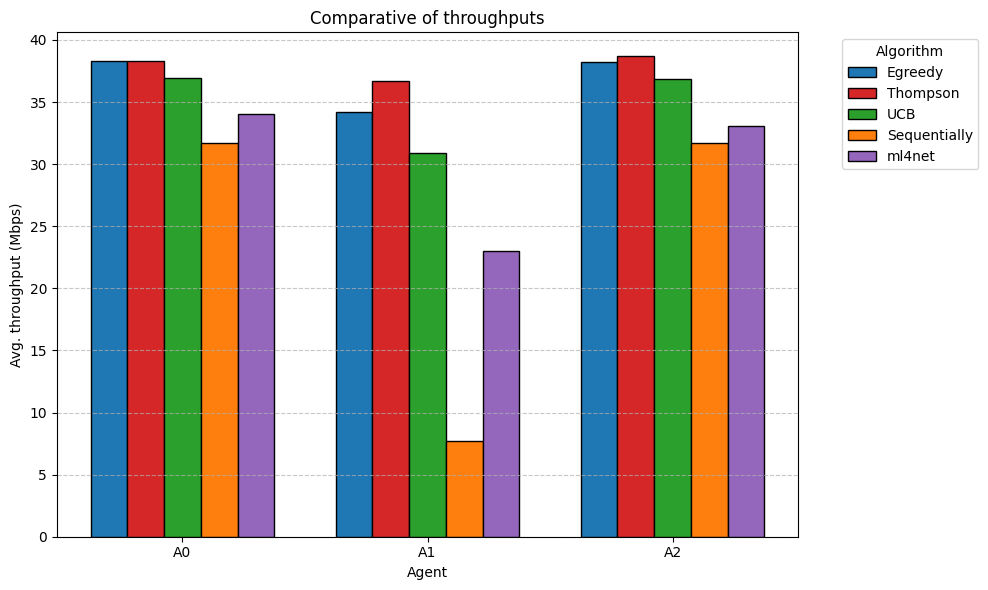

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# We define our data
data = np.array(means_all)

# We define the names of the experiments and agents
experiments = ['Egreedy', 'Thompson', 'UCB', 'Sequentially', 'ml4net']
agents = ['A0', 'A1', 'A2']

# We define the colors we will use for the bars and its width
colors = ['tab:blue', 'tab:red', 'tab:green', 'tab:orange', 'tab:purple']
x = np.arange(len(agents))
width = 0.15

# We plot the average throughput
fig, ax = plt.subplots(figsize=(10, 6))

for i in range(len(experiments)):
    ax.bar(
        x + i * width,
        data[i, :],
        width=width,
        label=experiments[i],
        color=colors[i],
        edgecolor='black'
    )

ax.set_xlabel('Agent')
ax.set_ylabel('Avg. throughput (Mbps)')
ax.set_title('Comparative of throughputs')
ax.set_xticks(x + width * (len(experiments) - 1) / 2)
ax.set_xticklabels(agents)
ax.grid(axis='y', linestyle='--', alpha=0.7)

ax.legend(title='Algorithm', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.legend(title='Algorithm')


plt.tight_layout()
plt.show()


Across all agents (A0, A1, A2), Thompson shows higher performance, being the most consistent and efficient. Egreedy and UCB maintain quite similar performance to Thompson on A0 and A2. On A1, they drop slightly (especially UCB), but remain good alternatives depending on the context. Sequentially drops sharply to 8 Mbps on agent A1, much lower than the other algorithms. This indicates that the algorithm does not adapt well to the network scenario. Although ml4net (our algorithm) outperforms Sequentially overall, its performance drops significantly on A1 (23 Mbps) compared to A0 and A2. This suggests that, although it is better than Sequentially, it still needs fine-tuning to be more robust in all cases.